In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU: []


In [ ]:
!pip install opendatasets -q
import opendatasets as od

od.download("https://www.kaggle.com/datasets/puneet6060/intel-image-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ap252143@gmail.com
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification


100%|██████████| 346M/346M [00:07<00:00, 51.8MB/s]


In [ ]:
data_dir = 'intel-image-classification'
train_dir = os.path.join(data_dir, 'seg_train', 'seg_train')
test_dir = os.path.join(data_dir, 'seg_test', 'seg_test')

class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
num_classes = len(class_names)

IMG_SIZE = 150
BATCH_SIZE = 32

print(f"Number of classes: {num_classes}")

Number of classes: 6
Number of training images: 6
Number of testing images: 6


In [ ]:
import os

def count_images_in_directory(directory):
    count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                count += 1
    return count

total_train_images = count_images_in_directory(train_dir)
total_test_images = count_images_in_directory(test_dir)

print(f"Correct number of training images: {total_train_images}")
print(f"Correct number of testing images: {total_test_images}")

Correct number of training images: 14034
Correct number of testing images: 3000


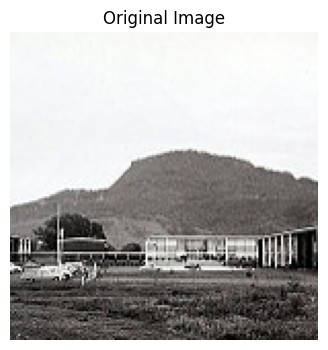

In [ ]:
sample_path = os.path.join(train_dir, 'buildings', '0.jpg')
sample_img = load_img(sample_path, target_size=(IMG_SIZE, IMG_SIZE))
sample_array = img_to_array(sample_img) / 255.0

plt.figure(figsize=(4, 4))
plt.imshow(sample_array)
plt.axis('off')
plt.title('Original Image')
plt.show()

## 1 - ImageDataGenerator (The classic way)

Pros:

  • Simple, well-documented

  • Built into Keras

  • flow_from_directory() is convenient

Cons:

  • CPU-based (slow)

  • Limited augmentations
  
  • Legacy approach

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

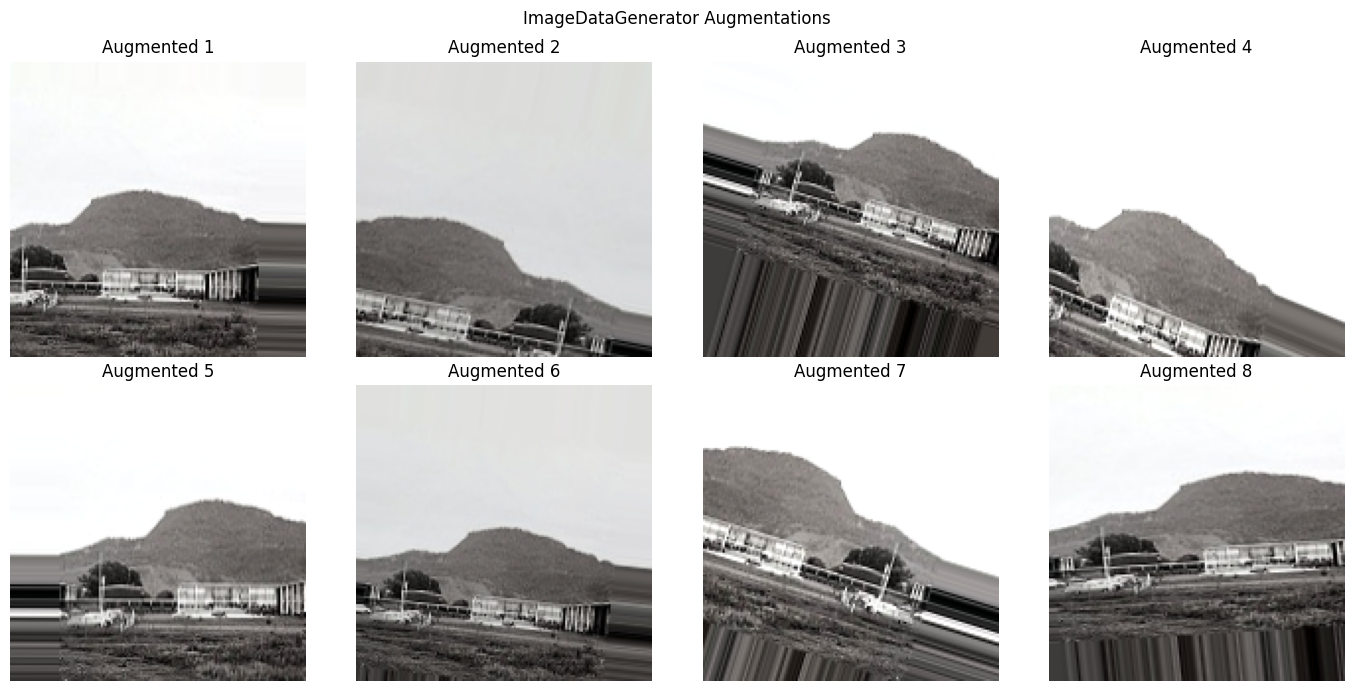

In [ ]:
#Visualizing the images
sample_batch = np.expand_dims(sample_array * 255, 0)  # Add batch dim

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

i = 0
for batch in datagen.flow(sample_batch, batch_size=1):
    axes[i].imshow(batch[0])
    axes[i].set_title(f'Augmented {i+1}')
    axes[i].axis('off')
    i += 1
    if i >= 8:
        break

plt.suptitle('ImageDataGenerator Augmentations')
plt.tight_layout()
plt.show()

## 2 - Using the Keras Layers

  • GPU-accelerated

  • Part of the model (saved together)

  • Can be toggled with training=True/False
  
  • Clean, modular

In [ ]:
new_data_aug_layer = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(height_factor=(-0.2, 0.2)),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomContrast(0.3)
], name='new_data_augmentation')

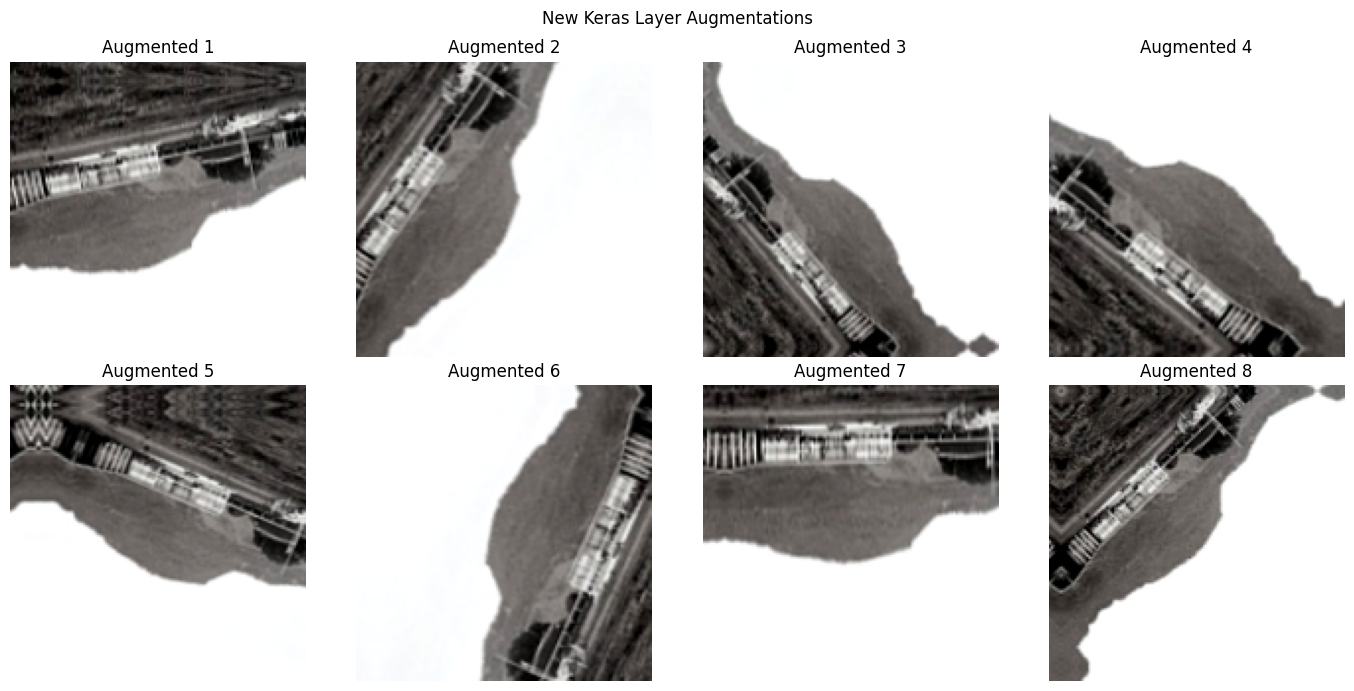

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    augmented = new_data_aug_layer(tf.expand_dims(sample_array, 0), training=True)
    # Clip the augmented image values to the valid range [0, 1] before displaying
    clipped_augmented = tf.clip_by_value(augmented[0], 0.0, 1.0)
    axes[i].imshow(clipped_augmented)
    axes[i].set_title(f'Augmented {i+1}')
    axes[i].axis('off')

plt.suptitle('New Keras Layer Augmentations')
plt.tight_layout()
plt.show()

## 3 - Albumentations

  • HUGE library of transforms (70+)

  • Very fast (optimized)

  • Industry standard for competitions

  • Works with bboxes, segmentation masks
  
  • Easy probability control per transform


In [ ]:
!pip install albumentations -q
import albumentations as A

/tmp/ipykernel_14047/3177433133.py:4: UserWarning: Argument(s) 'brigthness_limit' are not valid for transform RandomBrightnessContrast
  A.RandomBrightnessContrast(brigthness_limit=0.2, contrast_limit=0.2, p=0.5),
/tmp/ipykernel_14047/3177433133.py:6: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),


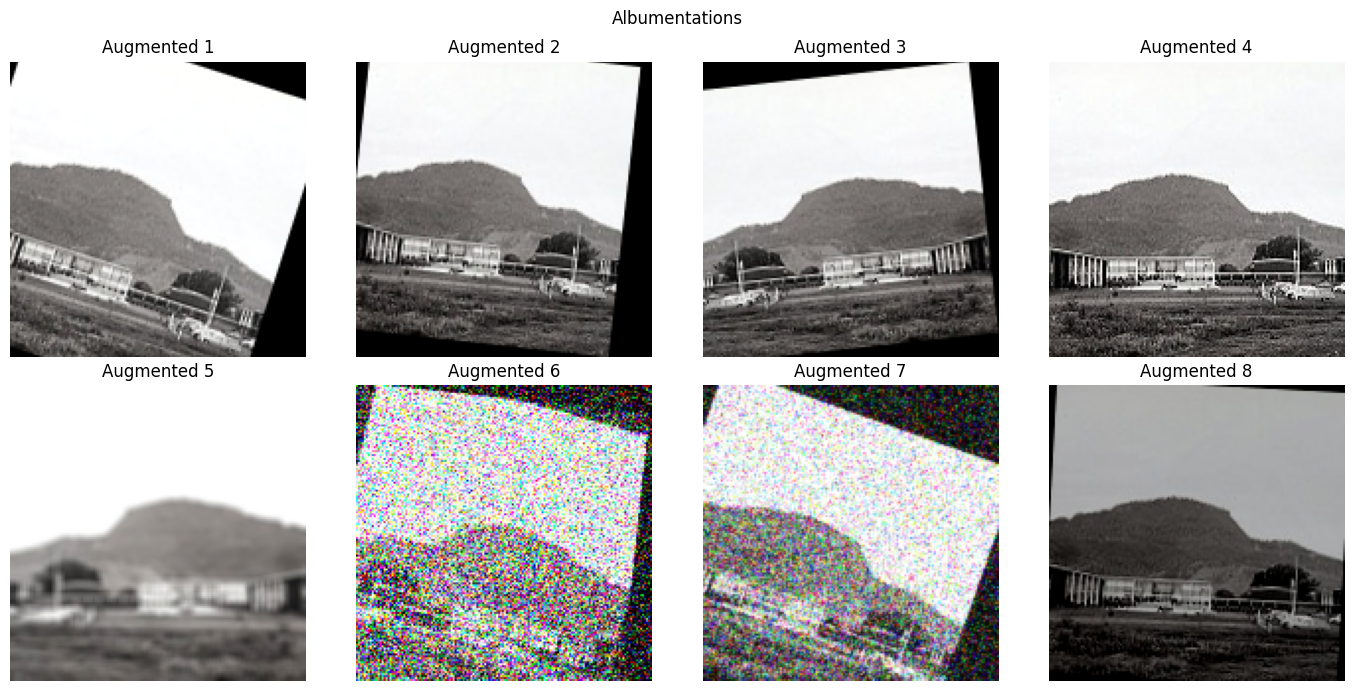

In [ ]:
album_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(brigthness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.5),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.3)
])

# Visualize Albumentations
sample_uint8 = (sample_array * 255).astype(np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    augmented = album_transform(image=sample_uint8)['image']
    axes[i].imshow(augmented)
    axes[i].set_title(f'Augmented {i+1}')
    axes[i].axis('off')

plt.suptitle('Albumentations')
plt.tight_layout()
plt.show()

## Advanced: Cutout, Mixup, Cutmix



Cutout - randomly masks out square patches of the input image, forcing the model to attend to less obvious features rather than relying on a single discriminative region. It's simple and effective, typically giving 1–2% accuracy boosts on CIFAR-level benchmarks. It doesn't modify labels.

Mixup - blends two images (and their labels) via linear interpolation: x = λ·x_i + (1-λ)·x_j. This acts as a strong regularizer, smooths decision boundaries, and improves calibration. It operates in input space (or even hidden layers in Manifold Mixup). Gains of 1–3% on CIFAR/ImageNet are common.

CutMix - it combines ideas from both Cutout and Mixup. It cuts a patch from one image and pastes it onto another, then mixes labels proportionally to patch area. The key advantage over Cutout is that no pixel is "wasted" on zeros, and over Mixup, that the mixed signal is spatially localized rather than ghostly. CutMix has shown consistent improvements on ImageNet (1–2% top-1), better localization (for tasks like object detection), and strong transfer learning gains.

In [ ]:
sample_path_sea = os.path.join(train_dir, 'sea', os.listdir(os.path.join(train_dir, 'sea'))[0])
sample_img2 = load_img(sample_path_sea, target_size=(IMG_SIZE, IMG_SIZE))
sample_array_sea = img_to_array(sample_img2) / 255.0

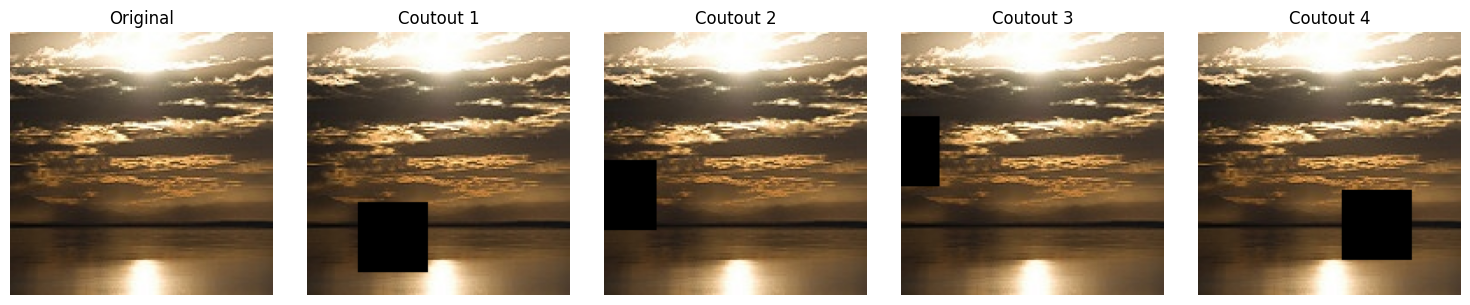

In [ ]:
# Implementing Cutout
def cutout(image, mask_size=50):
  h, w = image.shape[:2]

  #random center
  cx = np.random.randint(0, w)
  cy = np.random.randint(0, h)

  #calculating the bounds
  x1 = max(0, cx - mask_size // 2)
  x2 = min(w, cx + mask_size // 2)
  y1 = max(0, cy - mask_size // 2)
  y2 = min(h, cy + mask_size // 2)

  #Applying mask
  result = image.copy()
  result[y1:y2, x1:x2] = 0    # black-out region

  return result

# Visualizing the cutout
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(sample_array_sea)
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(4):
  cut_img = cutout(sample_array_sea, mask_size=40)
  axes[i+1].imshow(cut_img)
  axes[i+1].set_title(f'Coutout {i+1}')
  axes[i+1].axis('off')

plt.tight_layout()
plt.show()

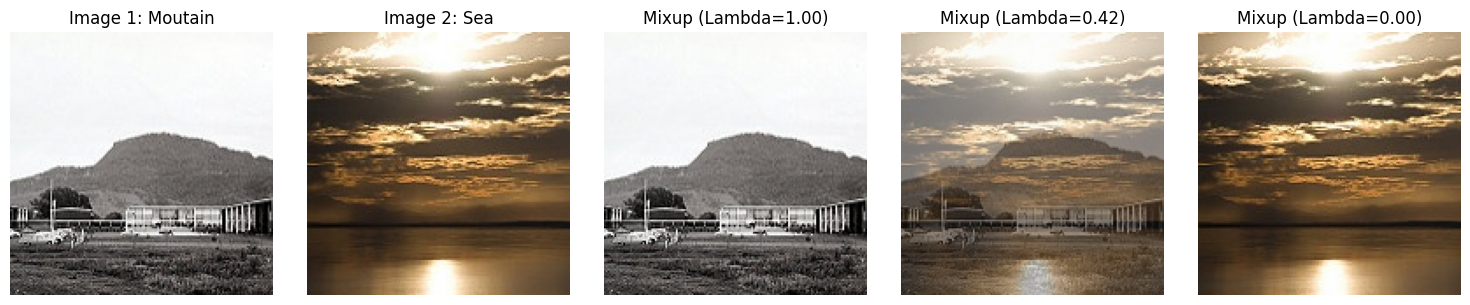

In [ ]:
#Implementing Mixup
def mixup(image1, image2, alpha=0.4):
  lam = np.random.beta(alpha, alpha)
  mixed = lam * image1 + (1 - lam) * image2
  return mixed, lam

#visualizing the mixup
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(sample_array)
axes[0].set_title('Image 1: Moutain')
axes[0].axis('off')

axes[1].imshow(sample_array_sea)
axes[1].set_title('Image 2: Sea')
axes[1].axis('off')

for i in range(3):
  mixed, lam = mixup(sample_array, sample_array_sea)
  axes[i+2].imshow(mixed)
  axes[i+2].set_title(f'Mixup (Lambda={lam:.2f})')
  axes[i+2].axis('off')

plt.tight_layout()
plt.show()

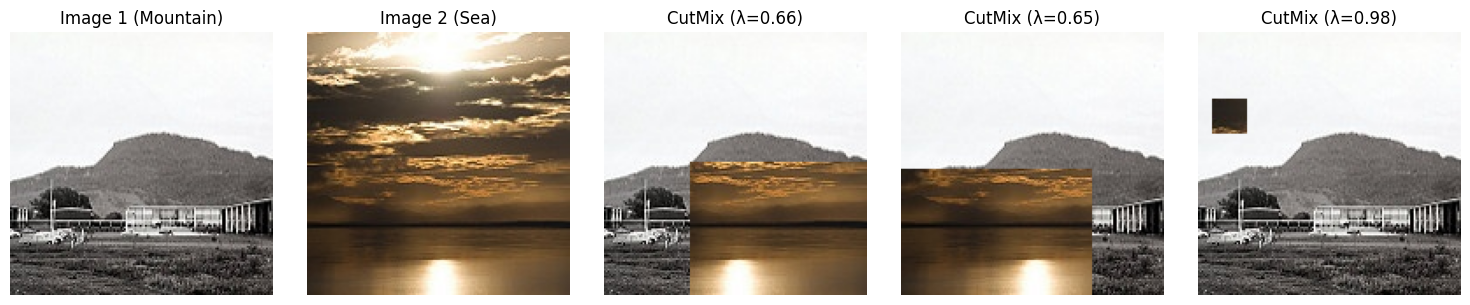

In [ ]:
# Implement CutMix
def cutmix(image1, image2, alpha=1.0):
    h, w = image1.shape[:2]
    lam = np.random.beta(alpha, alpha)

    # Calculate box size
    cut_ratio = np.sqrt(1 - lam)
    cut_w = int(w * cut_ratio)
    cut_h = int(h * cut_ratio)

    # Random center
    cx = np.random.randint(0, w)
    cy = np.random.randint(0, h)

    # Bounds
    x1 = max(0, cx - cut_w // 2)
    x2 = min(w, cx + cut_w // 2)
    y1 = max(0, cy - cut_h // 2)
    y2 = min(h, cy + cut_h // 2)

    # Cut and mix
    result = image1.copy()
    result[y1:y2, x1:x2] = image2[y1:y2, x1:x2]

    # Actual lambda based on box area
    lam_actual = 1 - (x2 - x1) * (y2 - y1) / (w * h)

    return result, lam_actual

# Visualize CutMix
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

axes[0].imshow(sample_array)
axes[0].set_title('Image 1 (Mountain)')
axes[0].axis('off')

axes[1].imshow(sample_array2)
axes[1].set_title('Image 2 (Sea)')
axes[1].axis('off')

for i in range(3):
    cutmixed, lam = cutmix(sample_array, sample_array2)
    axes[i+2].imshow(cutmixed)
    axes[i+2].set_title(f'CutMix (λ={lam:.2f})')
    axes[i+2].axis('off')

plt.tight_layout()
plt.show()

In practice, the hierarchy typically looks like this:

Albumentations (baseline pixel/geometric augmentation) → add CutMix or Mixup on top → see meaningful additional gains. The techniques are additive. A strong Albumentations pipeline alone can get you far, but CutMix/Mixup push generalization further by regularizing the loss landscape in ways pixel transforms can't.

Bottom line: If you're choosing, don't choose — use Albumentations for your base augmentation pipeline, then layer CutMix (or Mixup) on top during training. CutMix in particular has become a near-default in modern training recipes (timm, torchvision's new training scripts, etc.) because of its consistent gains across tasks.